# 군집 파트 코드 정리

---
## 목차
- 전처리 및 EDA
    - items
    - customers
    - payments
    - products
- 군집 진행
- 결과

---
## EDA 및 전처리

In [2]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
import pandas as pd

df_payments = pd.read_csv("olist_order_payments_dataset.csv")
df_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")
df_products = pd.read_csv("olist_products_dataset.csv")
df_items = pd.read_csv("olist_order_items_dataset.csv")

### olist_order_items_dataset.csv

In [4]:
# df_items에서 'order_id', 'price', 'freight_value'만 필터링
df_item_filter = df_items.loc[:, ['order_id', 'price', 'freight_value']]

# 출력 구분선 추가
print("\n" + "="*60)
print("1. item 데이터 (가격, 배송비)")
print("="*60)

# 데이터 정보 출력
print(f"Shape: {df_item_filter.shape}\n")

print("[Data Info]")
df_item_filter.info()

# 기초 통계량 출력
print("\n" + "="*60)
print("[기초 통계량]")
print("="*60)
print(df_item_filter.describe().T)

# 중복 행 수 출력
print("\n" + "="*60)
print("[item 중복 행 수]")
print("="*60)
print(f"{df_items.duplicated().sum()} 중복 행이 있습니다.")
print(f"{df_item_filter.duplicated().sum()} 중복 행이 있습니다.")


1. item 데이터 (가격, 배송비)
Shape: (112650, 3)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       112650 non-null  object 
 1   price          112650 non-null  float64
 2   freight_value  112650 non-null  float64
dtypes: float64(2), object(1)
memory usage: 2.6+ MB

[기초 통계량]
                  count        mean         std   min    25%    50%     75%  \
price          112650.0  120.653739  183.633928  0.85  39.90  74.99  134.90   
freight_value  112650.0   19.990320   15.806405  0.00  13.08  16.26   21.15   

                   max  
price          6735.00  
freight_value   409.68  

[item 중복 행 수]
0 중복 행이 있습니다.
11080 중복 행이 있습니다.


🤔 필터링한 거에서 중복 행이 많네? → `order_item_id` 컬럼을 제외시켰기 때문

[`order_item_id` 컬럼의 역할]

![order_item_id의 역할](https://velog.velcdn.com/images/yeppi1802/post/3a7f6237-1ff0-4247-a3f6-932bda2ebe66/image.png)

나는 카운트가 필요하기때문에 해당 컬럼이 필요 없음. 
때문에 발생하는 중복은 나에게 의미가 없음. → **중복을 삭제하지 않고 진행.**

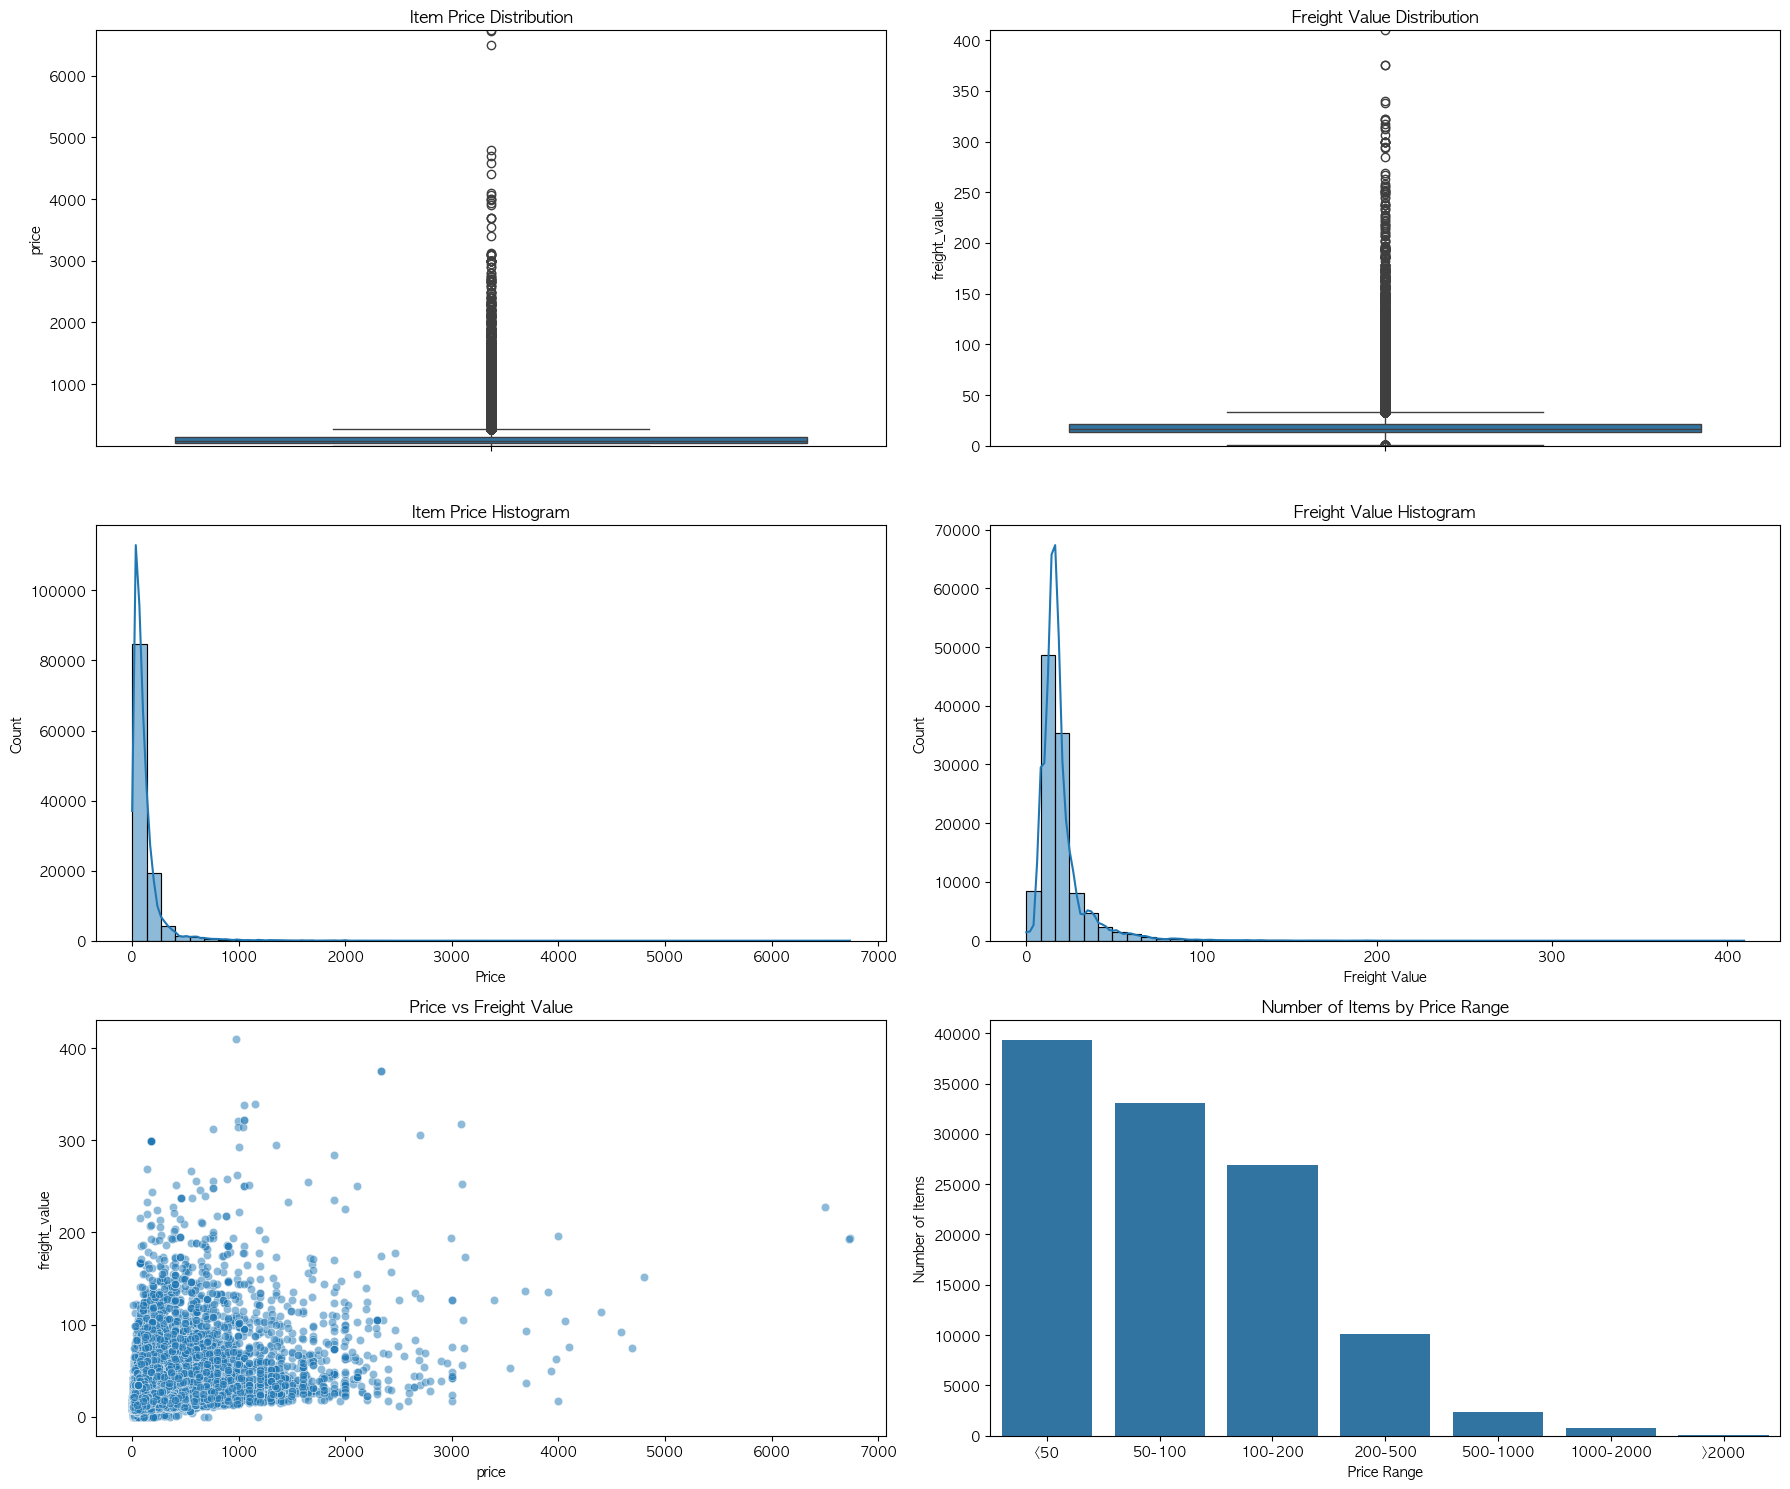

상관계수: 0.414


In [5]:
# 1. Boxplot, 2. Histogram, 3. Scatterplot, 4. Countplot을 모두 하나의 figure에 배치
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# 1. Price Boxplot
sns.boxplot(y='price', data=df_item_filter, ax=axes[0, 0])
axes[0, 0].set_title('Item Price Distribution')
axes[0, 0].set_ylim(df_item_filter['price'].min(), df_item_filter['price'].max())

# 2. Freight Value Boxplot
sns.boxplot(y='freight_value', data=df_item_filter, ax=axes[0, 1])
axes[0, 1].set_title('Freight Value Distribution')
axes[0, 1].set_ylim(df_item_filter['freight_value'].min(), df_item_filter['freight_value'].max())

# 3. Item Price Histogram
sns.histplot(df_item_filter['price'], bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Item Price Histogram')
axes[1, 0].set_xlabel('Price')
axes[1, 0].set_ylabel('Count')

# 4. Freight Value Histogram
sns.histplot(df_item_filter['freight_value'], bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Freight Value Histogram')
axes[1, 1].set_xlabel('Freight Value')
axes[1, 1].set_ylabel('Count')

# 5. Price vs Freight Value Scatterplot
sns.scatterplot(data=df_item_filter, x='price', y='freight_value', alpha=0.5, ax=axes[2, 0])
axes[2, 0].set_title('Price vs Freight Value')

# 6. Number of Items by Price Range (Countplot)
# Price 구간 나눠서 그룹별로 보기
df_item_filter['price_cut'] = pd.cut(df_item_filter['price'],
                                     bins=[0, 50, 100, 200, 500, 1000, 2000, 4000],
                                     labels=['<50', '50-100', '100-200', '200-500', '500-1000', '1000-2000', '>2000'])
sns.countplot(data=df_item_filter, x='price_cut', order=df_item_filter['price_cut'].cat.categories, ax=axes[2, 1])
axes[2, 1].set_title('Number of Items by Price Range')
axes[2, 1].set_xlabel('Price Range')
axes[2, 1].set_ylabel('Number of Items')

# 자동 레이아웃 조정
plt.tight_layout()
plt.show()

corr = df_item_filter['price'].corr(df_item_filter['freight_value'])
print(f'상관계수: {corr:.3f}')


🤔

가격이 낮으면 당연히 배송비도 낮을 것이라 예상했으나, 생각보다 약한 상관관계를 가지는군.

🤖

전체적으로 점들이 삼각형 모양으로 펼쳐져 있음   
→ 저가 상품은 모든 배송비 구간에 존재하지만,    
고가 상품은 낮은 배송비 구간에 상대적으로 적음. 

=> 즉, **상품가가 높을수록 낮은 배송비를 선택하기 어렵다는 현실적 패턴 반영 가능.**

### olist_customers_dataset.csv

In [6]:
# df_customers에서 'customer_id'와 'customer_unique_id'만 필터링
df_customer_filter = df_customers.loc[:, ['customer_id', 'customer_unique_id']]

# 출력 구분선 추가
print("\n" + "="*60)
print("2. customer 데이터")
print("="*60)

# 데이터 정보 출력
print(f"Shape: {df_customer_filter.shape}\n")

print("[Data Info]")
df_customer_filter.info()

# 기초 통계량 출력
print("\n" + "="*60)
print("[기초 통계량]")
print("="*60)
print(df_customer_filter.describe().T)
""" 
- `customer_id`는 주문 마다 생기는 고객 id

- `customer_unique_id`는 고객 고유 id

그렇다면, cnt(`customer_id)` - cnt(`customer_unique_id`) = 재구매 횟수 -> 3,345건(3.4%)
"""

print("\n" + "="*60)
print(f"\n[customer 중복 행 수] {df_customers.duplicated().sum()}")


2. customer 데이터
Shape: (99441, 2)

[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         99441 non-null  object
 1   customer_unique_id  99441 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB

[기초 통계량]
                    count unique                               top freq
customer_id         99441  99441  06b8999e2fba1a1fbc88172c00ba8bc7    1
customer_unique_id  99441  96096  8d50f5eadf50201ccdcedfb9e2ac8455   17


[customer 중복 행 수] 0


In [7]:
# customer_unique_id 기준으로 주문 횟수 계산
order_count_per_cui = df_customer_filter.groupby('customer_unique_id')['customer_id'].count().reset_index()
order_count_per_cui.columns = ['customer_unique_id', 'order_count']

# 상위 15명 고객의 주문 횟수 출력
print("\n" + "="*60)
print("3. 기존 고객당 주문 횟수")
print("="*60)

display(order_count_per_cui.sort_values(by='order_count', ascending=False).head(15))

# 2회 이상 구매한 고객의 수
print("\n" + "="*60)
print("4. 2회 이상 구매한 고객의 수")
print("="*60)

display(order_count_per_cui[order_count_per_cui['order_count'] >= 2].count())

# 재구매 누적 비율 계산
order_counts_ratio = order_count_per_cui['order_count'].value_counts(normalize=True).sort_index().cumsum()



3. 기존 고객당 주문 횟수


,customer_unique_id,order_count
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6
83540,de34b16117594161a6a89c50b289d35a,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
90451,f0e310a6839dce9de1638e0fe5ab282a,6
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6



4. 2회 이상 구매한 고객의 수


customer_unique_id    2997
order_count           2997
dtype: int64

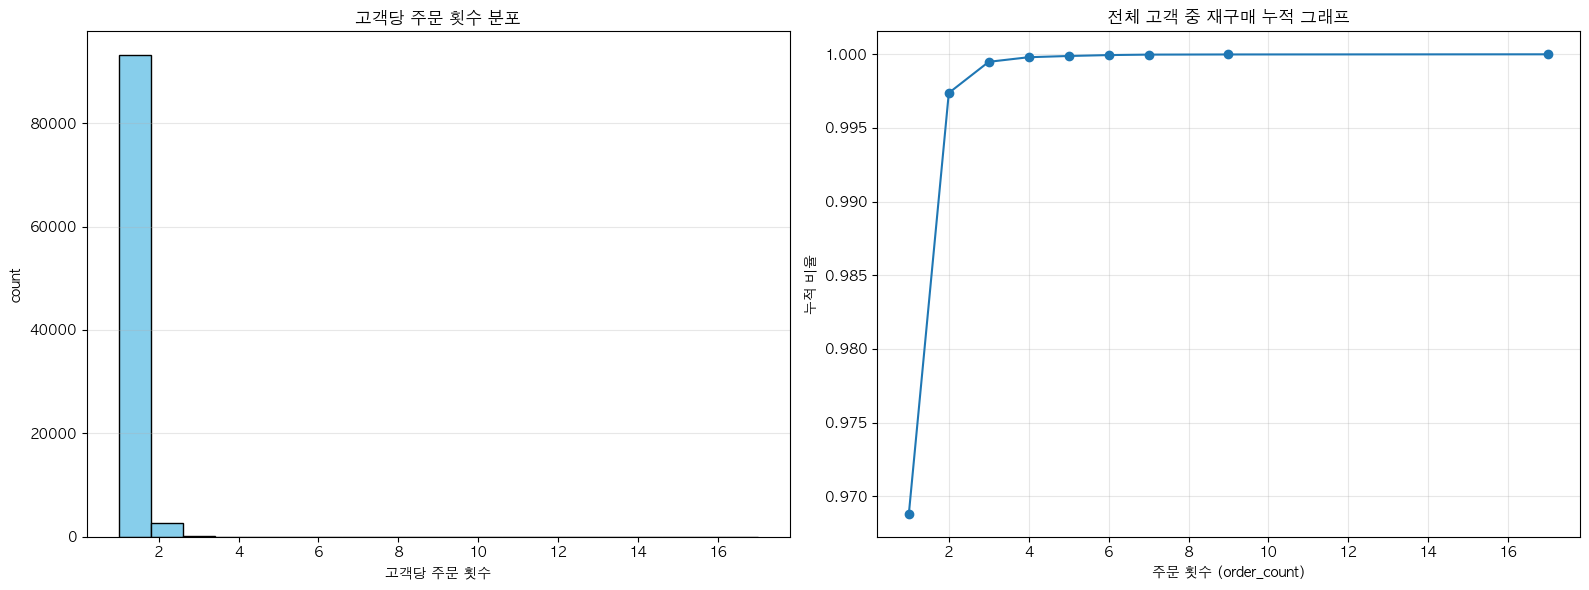

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 고객당 주문 횟수 히스토그램
axes[0].hist(order_count_per_cui['order_count'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('고객당 주문 횟수 분포')
axes[0].set_xlabel('고객당 주문 횟수')
axes[0].set_ylabel('count')
axes[0].grid(axis='y', alpha=0.3)

# 재구매 누적 비율 그래프
axes[1].plot(order_counts_ratio.index, order_counts_ratio.values, marker='o')
axes[1].set_title('전체 고객 중 재구매 누적 그래프')
axes[1].set_xlabel('주문 횟수 (order_count)')
axes[1].set_ylabel('누적 비율')
axes[1].grid(True, alpha=0.3)

# 레이아웃 자동 조정
plt.tight_layout()
plt.show()


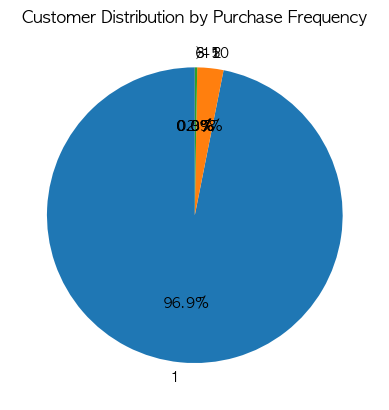

In [9]:
# 파이차트로 봐볼까
order_bins = pd.cut(order_count_per_cui['order_count'], bins=[0,1,2,5,11,21],
                    labels=['1', '2', '3-5', '6-10', '>11'])
order_bins.value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Customer Distribution by Purchase Frequency')
plt.ylabel('')
plt.show()

### olist_order_payments_dataset.csv

In [10]:
# 'payment_value' 컬럼에서 중복 값 개수 확인
print("\n" + "="*60)
print("5. payment_value 중복 값 확인")
print("="*60)

duplicated_count = df_payments['payment_value'].duplicated().sum()
print(f"중복된 payment_value의 개수: {duplicated_count}")

# 'payment_value' 기초 통계량 출력
print("\n" + "="*60)
print("payment_value 기초 통계량")
print("="*60)

purchase = df_payments['payment_value']
print(purchase.describe())

print("\n" + "="*60)
print("고유값 확인")
print("="*60)
print(df_payments['payment_type'].unique())
print(df_payments['payment_installments'].unique())


5. payment_value 중복 값 확인
중복된 payment_value의 개수: 74809

payment_value 기초 통계량
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

고유값 확인
['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']
[ 8  1  2  3  6  5  4 10  7 12  9 13 15 24 11 18 14 20 21 17 22  0 16 23]



6. 결제금액 구간별 분포


payment_value
(-13.664, 1366.408]       103317
(1366.408, 2732.816]         501
(2732.816, 4099.224]          54
(4099.224, 5465.632]           8
(5465.632, 6832.04]            2
(6832.04, 8198.448]            3
(8198.448, 9564.856]           0
(9564.856, 10931.264]          0
(10931.264, 12297.672]         0
(12297.672, 13664.08]          1
Name: count, dtype: int64


고객 결제금액 분포 분석
[결제금액 통계]
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

왜도(Skewness): 9.254
첨도(Kurtosis): 241.817


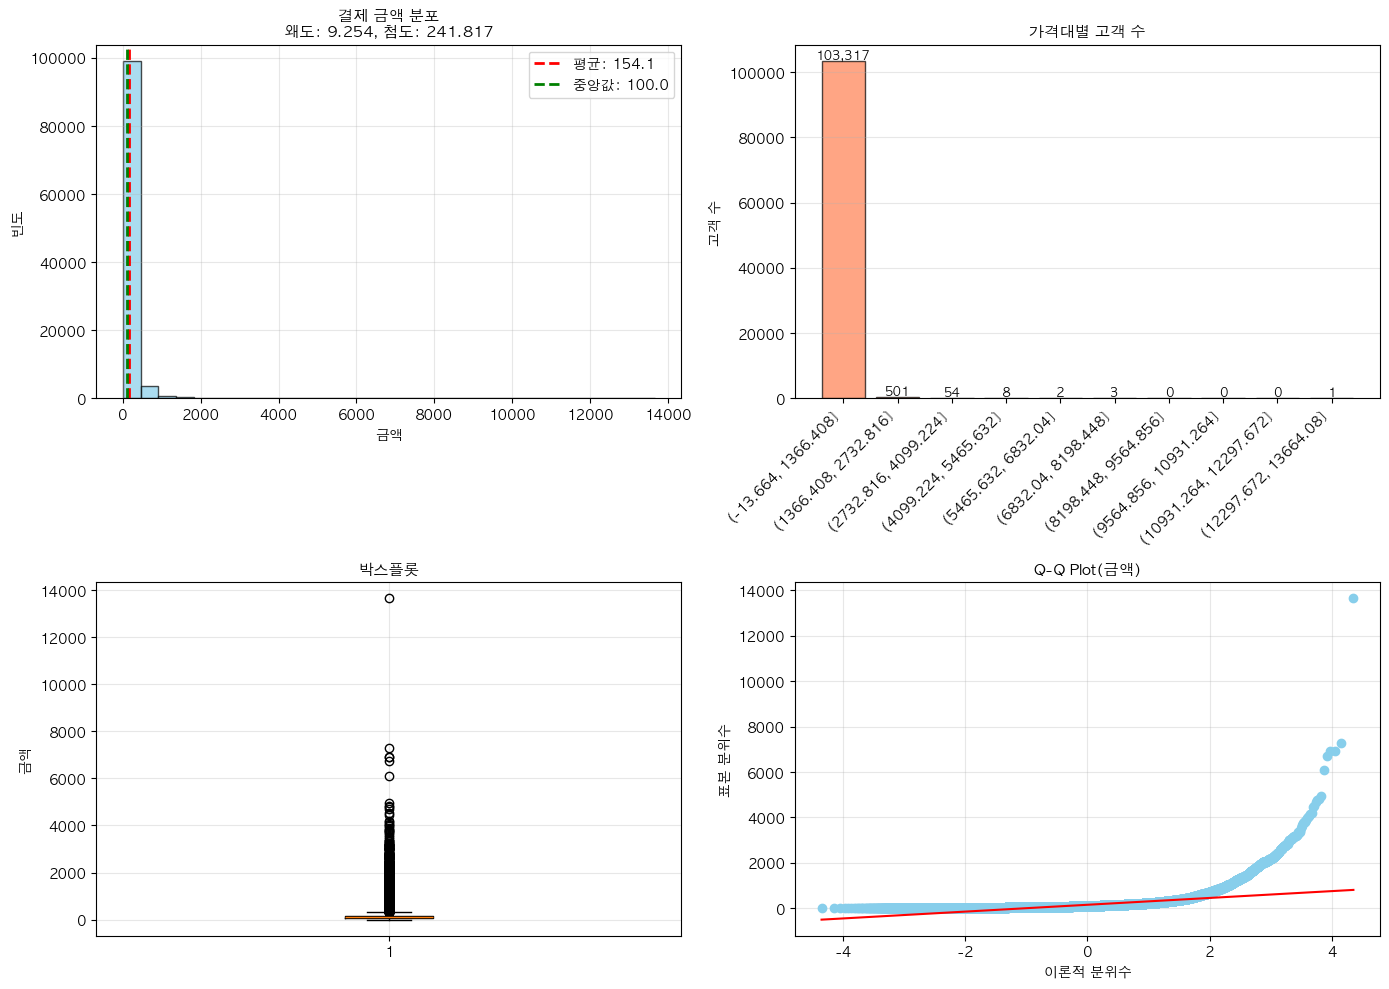

"\n대부분의 고객이 저가 상품을 구매\n특정 가격대에 구매가 집중됨(고객들이 선호하는 '스위트 스팟' 가격대)\n"

In [11]:
# 최솟값~최댓값을 10개 구간으로 균등 분할
payment_bins = pd.cut(df_payments['payment_value'], bins=10)
print("\n" + "="*60)
print("6. 결제금액 구간별 분포")
print("="*60)
display(payment_bins.value_counts().sort_index())

# 결제금액 통계 출력
print("\n" + "="*60)
print("고객 결제금액 분포 분석")
print("="*60)

# 결제금액 통계 출력
print("[결제금액 통계]")
print(df_payments['payment_value'].describe())

# 왜도와 첨도 계산
from scipy.stats import skew, kurtosis
purchase_skew = skew(df_payments['payment_value'])
purchase_kurt = kurtosis(df_payments['payment_value'])
print(f"\n왜도(Skewness): {purchase_skew:.3f}")
print(f"첨도(Kurtosis): {purchase_kurt:.3f}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 히스토그램
axes[0, 0].hist(df_payments['payment_value'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(df_payments['payment_value'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'평균: {df_payments["payment_value"].mean():.1f}')
axes[0, 0].axvline(df_payments['payment_value'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'중앙값: {df_payments["payment_value"].median():.1f}')
axes[0, 0].set_title(f'결제 금액 분포\n왜도: {purchase_skew:.3f}, 첨도: {purchase_kurt:.3f}', 
                     fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('금액')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 가격대별 분포
purchase_group_counts = payment_bins.value_counts().sort_index()
axes[0, 1].bar(range(len(purchase_group_counts)), purchase_group_counts.values, 
               color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(purchase_group_counts)))
axes[0, 1].set_xticklabels(purchase_group_counts.index, rotation=45, ha='right')
axes[0, 1].set_title('가격대별 고객 수', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 각 막대 위에 개수 표시
for i, count in enumerate(purchase_group_counts.values):
    axes[0, 1].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

# 3. 박스플롯
axes[1, 0].boxplot(df_payments['payment_value'], vert=True)
axes[1, 0].set_title('박스플롯', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('금액')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot
import scipy.stats as stats
stats.probplot(df_payments['payment_value'], dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_markerfacecolor('skyblue')
axes[1, 1].get_lines()[0].set_markeredgecolor('skyblue')
axes[1, 1].set_title('Q-Q Plot(금액)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('이론적 분위수')
axes[1, 1].set_ylabel('표본 분위수')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

"""
대부분의 고객이 저가 상품을 구매
특정 가격대에 구매가 집중됨(고객들이 선호하는 '스위트 스팟' 가격대)
"""


고객 결제금액 (로그 변환) 분포 분석
[로그 변환 후 결제금액 통계]
count    103886.000000
mean          4.615135
std           0.906060
min           0.000000
25%           4.056816
50%           4.615121
75%           5.152352
max           9.522599
Name: log_payment_value, dtype: float64

왜도(Skewness): -0.169
첨도(Kurtosis): 1.890

로그 변환 후 결제금액 구간별 분포


log_payment_value
(-0.00952, 0.952]      275
(0.952, 1.905]         629
(1.905, 2.857]        1430
(2.857, 3.809]       14648
(3.809, 4.761]       42250
(4.761, 5.714]       34521
(5.714, 6.666]        8244
(6.666, 7.618]        1699
(7.618, 8.57]          184
(8.57, 9.523]            6
Name: count, dtype: int64

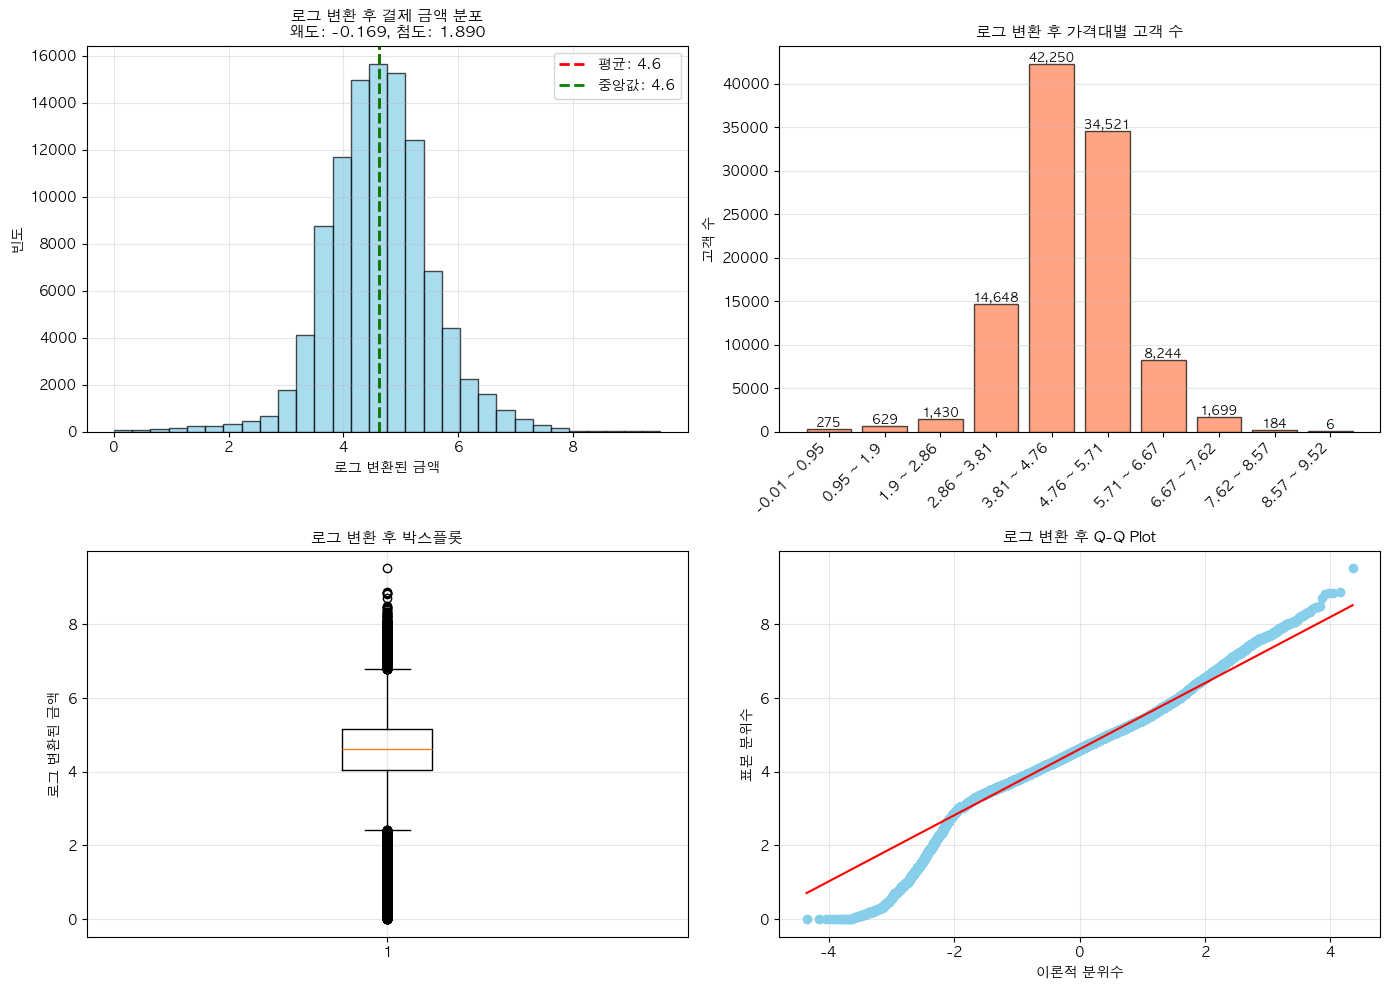

In [12]:
# 로그 변환 (0보다 작은 값은 제외)
df_payments['log_payment_value'] = np.log1p(df_payments['payment_value'])  # log1p는 log(1+x)를 계산

print("\n" + "="*60)
print("고객 결제금액 (로그 변환) 분포 분석")
print("="*60)

# 통계
print("[로그 변환 후 결제금액 통계]")
print(df_payments['log_payment_value'].describe())

# 왜도와 첨도
purchase_skew_log = skew(df_payments['log_payment_value'])
purchase_kurt_log = kurtosis(df_payments['log_payment_value'])
print(f"\n왜도(Skewness): {purchase_skew_log:.3f}")
print(f"첨도(Kurtosis): {purchase_kurt_log:.3f}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 히스토그램
axes[0, 0].hist(df_payments['log_payment_value'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(df_payments['log_payment_value'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'평균: {df_payments["log_payment_value"].mean():.1f}')
axes[0, 0].axvline(df_payments['log_payment_value'].median(), color='green', linestyle='--', linewidth=2,
                   label=f'중앙값: {df_payments["log_payment_value"].median():.1f}')
axes[0, 0].set_title(f'로그 변환 후 결제 금액 분포\n왜도: {purchase_skew_log:.3f}, 첨도: {purchase_kurt_log:.3f}', 
                     fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('로그 변환된 금액')
axes[0, 0].set_ylabel('빈도')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 가격대별 분포 (로그 변환된 값으로 구간 나누기)
payment_bins_log = pd.cut(df_payments['log_payment_value'], bins=10)
print("\n" + "="*60)
print("로그 변환 후 결제금액 구간별 분포")
print("="*60)
display(payment_bins_log.value_counts().sort_index())

purchase_group_counts_log = payment_bins_log.value_counts().sort_index()
axes[0, 1].bar(range(len(purchase_group_counts_log)), purchase_group_counts_log.values, 
               color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(purchase_group_counts_log)))
axes[0, 1].set_xticklabels([f'{round(interval.left, 2)} ~ {round(interval.right, 2)}' 
                            for interval in purchase_group_counts_log.index], rotation=45, ha='right')
axes[0, 1].set_title('로그 변환 후 가격대별 고객 수', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 각 막대 위에 개수 표시
for i, count in enumerate(purchase_group_counts_log.values):
    axes[0, 1].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

# 3. 박스플롯
axes[1, 0].boxplot(df_payments['log_payment_value'], vert=True)
axes[1, 0].set_title('로그 변환 후 박스플롯', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('로그 변환된 금액')
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q plot
import scipy.stats as stats
stats.probplot(df_payments['log_payment_value'], dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_markerfacecolor('skyblue')
axes[1, 1].get_lines()[0].set_markeredgecolor('skyblue')
axes[1, 1].set_title('로그 변환 후 Q-Q Plot', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('이론적 분위수')
axes[1, 1].set_ylabel('표본 분위수')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### olist_products_dataset.csv

In [13]:
# 카테고리행 영어로 대치
translation = pd.read_csv('product_category_name_translation.csv')

# 선 병합
df_products = df_products.dropna(subset=['product_category_name'])
df_products = df_products.merge(translation, on='product_category_name', how='left')
print(df_products['product_category_name_english'].isnull().sum())

# 결측값 확인
cond = df_products['product_category_name_english'].isnull()
display(df_products.loc[cond, ['product_category_name', 'product_category_name_english']])

# 결측값 대체
df_products['product_category_name_english'] = df_products['product_category_name_english'].fillna('portable_kitchen_food_preparers')

# 특정 행에 대해 값 수정
df_products.loc[[1581, 7326, 16609], 'product_category_name_english'] = 'pc_gamer'

# 컬럼 내용 변경 확인
print('컬럼 내용 변경 확인')
display(df_products[df_products['product_category_name_english'] == 'portable_kitchen_food_preparers'])
print('\n')
display(df_products[df_products['product_category_name_english'] == 'pc_gamer'])


13


,product_category_name,product_category_name_english
1581,pc_gamer,NaN
5703,portateis_cozinha_e_preparadores_de_alimentos,NaN
7176,portateis_cozinha_e_preparadores_de_alimentos,NaN
7326,pc_gamer,NaN
8648,portateis_cozinha_e_preparadores_de_alimentos,NaN
10823,portateis_cozinha_e_preparadores_de_alimentos,NaN
13996,portateis_cozinha_e_preparadores_de_alimentos,NaN
15875,portateis_cozinha_e_preparadores_de_alimentos,NaN
16609,pc_gamer,NaN
17460,portateis_cozinha_e_preparadores_de_alimentos,NaN


컬럼 내용 변경 확인


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
5703,6fd83eb3e0799b775e4f946bd66657c0,portateis_cozinha_e_preparadores_de_alimentos,52.0,280.0,1.0,1200.0,25.0,33.0,25.0,portable_kitchen_food_preparers
7176,5d923ead886c44b86845f69e50520c3e,portateis_cozinha_e_preparadores_de_alimentos,58.0,284.0,1.0,1200.0,25.0,33.0,25.0,portable_kitchen_food_preparers
8648,bed164d9d628cf0593003389c535c6e0,portateis_cozinha_e_preparadores_de_alimentos,54.0,382.0,2.0,850.0,30.0,21.0,22.0,portable_kitchen_food_preparers
10823,1220978a08a6b29a202bc015b18250e9,portateis_cozinha_e_preparadores_de_alimentos,46.0,280.0,1.0,1200.0,25.0,33.0,25.0,portable_kitchen_food_preparers
13996,ae62bb0f95af63d64eae5f93dddea8d3,portateis_cozinha_e_preparadores_de_alimentos,59.0,927.0,1.0,10600.0,40.0,20.0,38.0,portable_kitchen_food_preparers
15875,1954739d84629e7323a4295812a3e0ec,portateis_cozinha_e_preparadores_de_alimentos,58.0,792.0,4.0,750.0,30.0,30.0,30.0,portable_kitchen_food_preparers
17460,c7a3f1a7f9eef146cc499368b578b884,portateis_cozinha_e_preparadores_de_alimentos,52.0,1372.0,5.0,7350.0,40.0,30.0,23.0,portable_kitchen_food_preparers
18252,7afdd65f79f63819ff5bee328843fa37,portateis_cozinha_e_preparadores_de_alimentos,48.0,305.0,1.0,750.0,20.0,20.0,20.0,portable_kitchen_food_preparers
26398,a4756663d007b0cd1af865754d08d968,portateis_cozinha_e_preparadores_de_alimentos,60.0,1304.0,4.0,650.0,22.0,6.0,14.0,portable_kitchen_food_preparers
29370,cb9d764f38ee4d0c00af64d5c388f837,portateis_cozinha_e_preparadores_de_alimentos,57.0,306.0,1.0,625.0,28.0,27.0,24.0,portable_kitchen_food_preparers


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
1581,0105b5323d24fc655f73052694dbbb3a,pc_gamer,59.0,621.0,4.0,2839.0,19.0,16.0,18.0,pc_gamer
7326,6727051471a0fc4a0e7737b57bff2549,pc_gamer,60.0,1532.0,3.0,650.0,16.0,22.0,20.0,pc_gamer
16609,dbe520fb381ad695a7e1f2807d20c765,pc_gamer,60.0,840.0,6.0,800.0,18.0,22.0,22.0,pc_gamer


In [14]:
# 컬럼 대분류
cat_map = {
    # 패션·의류·잡화
    'fashion_male_clothing': 'fashion',
    'fashion_female_clothing': 'fashion',
    'fashion_shoes': 'fashion',
    'fashion_bags_accessories': 'fashion',
    'fashion_underwear_beach': 'fashion',
    'fashion_childrens_clothes': 'fashion',
    'fashion_sport': 'fashion',

    # 가구·인테리어
    'furniture_bedroom': 'furniture_home',
    'furniture_living_room': 'furniture_home',
    'furniture_mattress_and_upholstery': 'furniture_home',
    'furniture_decor': 'furniture_home',
    'home_confort': 'furniture_home',
    'home_confort_2': 'furniture_home',
    'bed_bath_table': 'furniture_home',

    # 생활·주방용품
    'housewares': 'home_kitchen',
    'kitchen_dining_laundry_garden_furniture': 'home_kitchen',
    'la_cuisine': 'home_kitchen',
    'portable_kitchen_food_preparers': 'home_kitchen',
    'small_appliances': 'home_kitchen',
    'small_appliances_home_oven_and_coffee': 'home_kitchen',
    'home_appliances': 'home_kitchen',
    'home_appliances_2': 'home_kitchen',

    # 전자제품
    'computers': 'electronics',
    'computers_accessories': 'electronics',
    'electronics': 'electronics',
    'telephony': 'electronics',
    'fixed_telephony': 'electronics',
    'audio': 'electronics',

    # 게임·엔터테인먼트
    'consoles_games': 'games',
    'pc_gamer': 'games',
    'cool_stuff': 'games',

    # 유아·육아
    'baby': 'baby_kids',
    'diapers_and_hygiene': 'baby_kids',

    # 뷰티·헬스케어
    'health_beauty': 'health_beauty',
    'perfumery': 'health_beauty',

    # 건축·공구·산업자재
    'construction_tools_construction': 'construction_tools',
    'construction_tools_garden': 'construction_tools',
    'construction_tools_lights': 'construction_tools',
    'construction_tools_safety': 'construction_tools',
    'costruction_tools_tools': 'construction_tools',
    'home_construction': 'construction_tools',

    # 자동차
    'auto': 'automotive',

    # 도서·출판·미디어
    'books_general_interest': 'books_media',
    'books_imported': 'books_media',
    'books_technical': 'books_media',
    'cds_dvds_musicals': 'books_media',
    'dvds_blu_ray': 'books_media',
    'cine_photo': 'books_media',
    'musical_instruments': 'books_media',
    'music': 'books_media',

    # 문구·사무
    'office_furniture': 'office_supplies',
    'stationery': 'office_supplies',

    # 식품·음료
    'food': 'food_drink',
    'food_drink': 'food_drink',
    'drinks': 'food_drink',
    'party_supplies': 'food_drink',

    # 반려동물
    'pet_shop': 'pet_supplies',

    # 가드닝
    'garden_tools': 'garden_flower',
    'flowers': 'garden_flower',

    # 취미·여가·스포츠
    'sports_leisure': 'leisure_sports',
    'christmas_supplies': 'leisure_sports',

    # 예술·공예
    'art': 'arts_crafts',
    'arts_and_craftsmanship': 'arts_crafts',

    # 여행·가방
    'luggage_accessories': 'travel',
    'watches_gifts': 'travel',

    # 산업·비즈니스·보안
    'industry_commerce_and_business': 'business_security',
    'security_and_services': 'business_security',
    'signaling_and_security': 'business_security',
    'agro_industry_and_commerce': 'business_security',
    'market_place': 'business_security',
}

# 매핑 적용
df_products['category_group'] = df_products['product_category_name'].map(cat_map)
df_products['category_group'] = df_products['category_group'].fillna('others')


---
## 군집 진행

In [15]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 시각화 기본 설정
plt.rcParams['figure.figsize'] = (12, 4)

# 전역 시드 설정
np.random.seed(42)

full_orders_geo = pd.read_csv("full_orders_geo.csv", index_col=0)



In [16]:
# # full_orders-geo 파일에 카테고리 추가!!

# # 3-1) 원본 상품 테이블
prod = pd.read_csv("olist_products_dataset.csv", usecols=['product_id','product_category_name'])

# # 3-2) 카테고리 번역 테이블
cat_map = pd.read_csv("product_category_name_translation.csv")  # columns: product_category_name, product_category_name_english

# # 3-3) 상품 → 번역 병합
prod = prod.merge(cat_map, on='product_category_name', how='left')

# # 수기 번역 추가
prod.loc[prod['product_category_name'] == 'pc_gamer', 'product_category_name_english'] = 'pc_gamer'
prod.loc[prod['product_category_name'] == 'portateis_cozinha_e_preparadores_de_alimentos', 'product_category_name_english'] = 'portable_kitchens_and_food_preparers'

# # 오타 수정
prod['product_category_name_english'] = prod['product_category_name_english'].replace({
    'fashio_female_clothing': 'fashion_female_clothing',
    'arts_and_craftmanship': 'arts_and_craftsmanship',
    'pc_gamer': 'pc_game',
    'home_comfort_2': 'home_confort_2'
})

# # 3-4) 주문 데이터에 product_category_name_english 붙이기
full_orders_geo = full_orders_geo.merge(prod[['product_id','product_category_name_english']], on='product_id', how='left')

# # ******** 주의 *********
# # full_orders_geo.to_csv("full_orders_geo.csv")

In [17]:
# -------------------------------
#  Haversine 거리 계산 함수
# -------------------------------
# 위도/경도를 라디안으로 변환
lat1 = np.radians(full_orders_geo['geolocation_lat_seller'])
lon1 = np.radians(full_orders_geo['geolocation_lng_seller'])
lat2 = np.radians(full_orders_geo['geolocation_lat_customer'])
lon2 = np.radians(full_orders_geo['geolocation_lng_customer'])

# 위도/경도 차이
dlat = lat2 - lat1
dlon = lon2 - lon1

# Haversine 공식 적용
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

# 거리 계산
full_orders_geo['distance_km'] = 6371 * c
full_orders_geo['road_distance_km'] = full_orders_geo['distance_km'] * 1.26

# # 지연일이 양수가 되게
# full_orders_geo['order_delivered_customer_date'] = pd.to_datetime(full_orders_geo['order_delivered_customer_date'])
# full_orders_geo['order_estimated_delivery_date'] = pd.to_datetime(full_orders_geo['order_estimated_delivery_date'])

# datetime 형변환
date_cols = [
    'order_delivered_carrier_date', 'shipping_limit_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
]
for col in date_cols:
    full_orders_geo[col] = pd.to_datetime(full_orders_geo[col], errors='coerce')

full_orders_geo['delay_days'] = (full_orders_geo['order_delivered_customer_date'] - full_orders_geo['order_estimated_delivery_date']).dt.days

# 지연여부 지연일 부호 바꾼고 헷갈려서 다시 확실히 정의
full_orders_geo['delay_label'] = full_orders_geo['delay_days'].apply(lambda x: 1 if x > 0 else 0)

In [18]:
region_group = {
    'AC': 'North', 'AP': 'North', 'AM': 'North', 'PA': 'North', 'RR': 'North', 'RO': 'North', 'TO': 'North',
    'MA': 'North East', 'PI': 'North East', 'North East': 'North East', 'RN': 'North East', 'PB': 'North East',
    'PE': 'North East', 'SE': 'North East', 'BA': 'North East', 'AL': 'North East', 'CE': 'North East',
    'MG': 'South East', 'RJ': 'South East', 'SP': 'South East', 'ES': 'South East',
    'PR': 'South', 'RS': 'South', 'SC': 'South',
    'GO': 'Central West', 'MS': 'Central West', 'MT': 'Central West', 'DF': 'Central West'
}

# 주 코드를 대문자로 통일
for col in ['seller_state','customer_state']:
    if col in full_orders_geo.columns:
        full_orders_geo[col] = full_orders_geo[col].astype(str).str.upper()

# 지역 매핑
full_orders_geo['seller_region'] = full_orders_geo['seller_state'].map(region_group)
full_orders_geo['customer_region'] = full_orders_geo['customer_state'].map(region_group)

# 매핑 실패(미등록 코드)는 'Unknown' 처리
full_orders_geo['seller_region']   = full_orders_geo['seller_region'].fillna('Unknown')
full_orders_geo['customer_region'] = full_orders_geo['customer_region'].fillna('Unknown')


In [19]:
# 71 -> 16 카테고리화 
# 1차 AI + 2차 수기 매칭(amazon 참고)
category_group = {
    # 패션·의류·잡화
    'fashion_male_clothing': 'fashion',
    'fashion_female_clothing': 'fashion',
    'fashion_shoes': 'fashion',
    'fashion_bags_accessories': 'fashion',
    'fashion_underwear_beach': 'fashion',
    'fashion_childrens_clothes': 'fashion',
    'fashion_sport': 'fashion',
    
    # 가구·인테리어    
    'furniture_bedroom': 'furniture_home',
    'furniture_living_room': 'furniture_home',
    'furniture_mattress_and_upholstery': 'furniture_home',
    'furniture_decor': 'furniture_home',
    'home_confort': 'furniture_home',
    'home_confort_2': 'furniture_home',
    'bed_bath_table': 'furniture_home',

    # 생활·주방용품
    'housewares': 'home_kitchen',
    'kitchen_dining_laundry_garden_furniture': 'home_kitchen',
    'la_cuisine': 'home_kitchen',
    'portable_kitchens_and_food_preparers': 'home_kitchen',
    'small_appliances': 'home_kitchen',
    'small_appliances_home_oven_and_coffee': 'home_kitchen',
    'home_appliances': 'home_kitchen',
    'home_appliances_2': 'home_kitchen',

    # 전자제품
    'computers': 'electronics',
    'computers_accessories': 'electronics',
    'electronics': 'electronics',
    'telephony': 'electronics',
    'fixed_telephony': 'electronics',
    'audio': 'electronics',
    'air_conditioning': 'electronics',

    # 게임
    'consoles_games': 'games',
    'pc_game': 'games',
    'cool_stuff': 'games',

    # 유아
    'baby': 'baby_kids',
    'diapers_and_hygiene': 'baby_kids',
    'toys': 'baby_kids',

    # 뷰티·헬스케어
    'health_beauty': 'health_beauty',
    'perfumery': 'health_beauty',

    # 건축·공구
    'construction_tools_construction': 'construction_tools',
    'construction_tools_garden': 'construction_tools',
    'construction_tools_lights': 'construction_tools',
    'construction_tools_safety': 'construction_tools',
    'costruction_tools_tools': 'construction_tools',
    'home_construction': 'construction_tools',

    # 자동차
    'auto': 'automotive',

    # 도서·출판·미디어
    'books_general_interest': 'books_media',
    'books_imported': 'books_media',
    'books_technical': 'books_media',
    'cds_dvds_musicals': 'books_media',
    'dvds_blu_ray': 'books_media',
    'cine_photo': 'books_media',
    'musical_instruments': 'books_media',
    'music': 'books_media',

    # 사무용품
    'office_furniture': 'office_supplies',
    'stationery': 'office_supplies',
    'tablets_printing_image': 'office_supplies',

    # 반려동물
    'pet_shop': 'pet_supplies',

    # 가드닝
    'garden_tools': 'garden_flower',
    'flowers': 'garden_flower',
    'costruction_tools_garden': 'garden_flower',

    # 스포츠
    'sports_leisure': 'leisure_sports',
    'christmas_supplies': 'leisure_sports',

    # 여행·가방
    'luggage_accessories': 'travel',
    'watches_gifts': 'travel',
    
    # 1700개 미만의 카테고리 -> 'others'
    # 식품·음료
    'food': 'others',
    'food_drink': 'others',
    'drinks': 'others',
    'party_supplies': 'others',
    # 예술·공예
    'art': 'others',
    'arts_and_craftsmanship': 'others',
    # 산업·비즈니스·보안
    'industry_commerce_and_business': 'others',
    'security_and_services': 'others',
    'signaling_and_security': 'others',
    'agro_industry_and_commerce': 'others',
    'market_place': 'others',
}

# 카테고리 그룹 매핑 (영문명을 기준으로)
full_orders_geo['product_category_group'] = full_orders_geo['product_category_name_english'].map(category_group).fillna('others')

In [20]:
# 개인확인용 삭제하셔도 됩니다.
# cols_check = [
#     'order_id','product_id','seller_state','customer_state',
#     'seller_region','customer_region',
#     'product_category_name_english','product_category_group'
# ]
# print(full_orders_geo[cols_check].head())

# # 분포 확인
# print(full_orders_geo['seller_region'].value_counts(dropna=False).head())
# print(full_orders_geo['customer_region'].value_counts(dropna=False).head())
# print(full_orders_geo['product_category_group'].value_counts(dropna=False).head())


---

# Clustering Preprocess

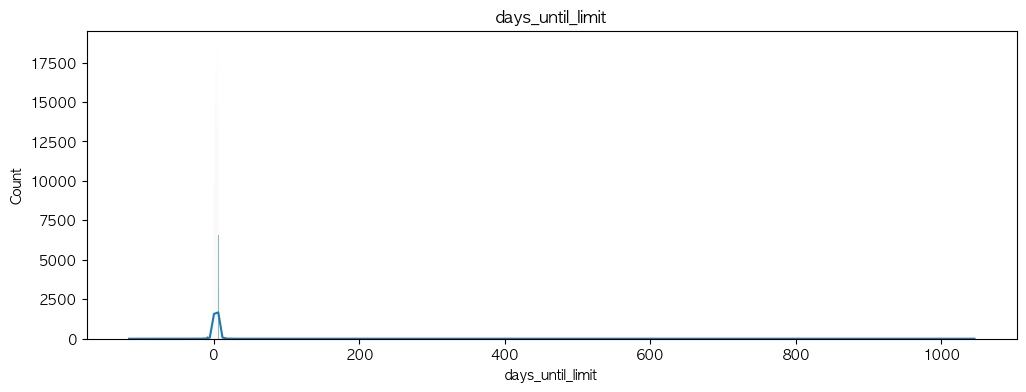

count    114047.000000
mean          2.819846
std           5.760623
min        -117.000000
25%           1.000000
50%           3.000000
75%           5.000000
max        1046.000000
Name: days_until_limit, dtype: float64


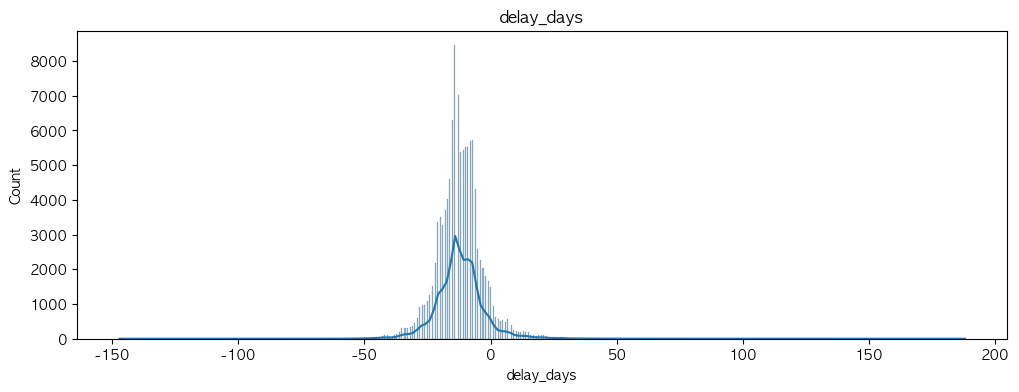

count    114047.000000
mean        -11.992336
std          10.176018
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delay_days, dtype: float64


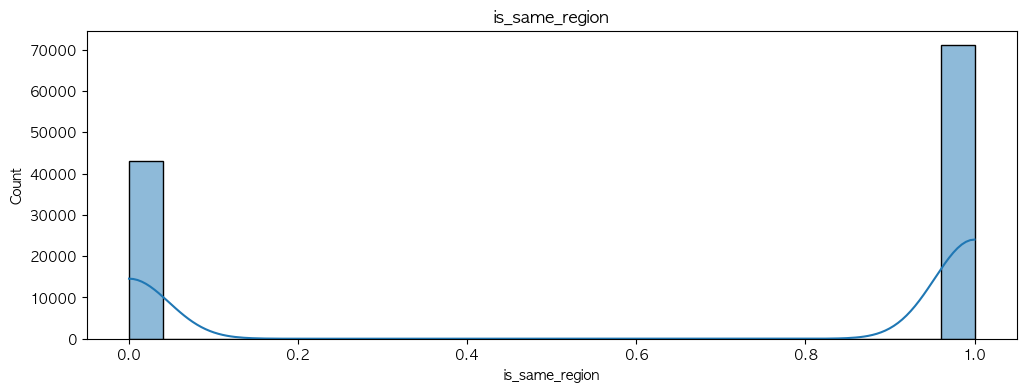

count    114047.000000
mean          0.622796
std           0.484689
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: is_same_region, dtype: float64


In [21]:
clustering_df = full_orders_geo.copy()

# 파생변수 변수 1. days_until_limit (출고여유: 판매자 출고 시점 - 마감기한)
clustering_df['days_until_limit'] = (clustering_df['shipping_limit_date'] - clustering_df['order_delivered_carrier_date']).dt.days

# 파생변수 2. is_same_region (로컬 내 거래)
clustering_df['is_same_region'] = np.where(clustering_df['seller_region'] == clustering_df['customer_region'], 1, 0)

# 전처리 전 분포 확인
for col in ['days_until_limit','delay_days','is_same_region']:
    sns.histplot(clustering_df[col], kde=True)
    plt.title(col)
    plt.show()
    print(clustering_df[col].describe())


In [22]:
# 데이터 분할
# 1. 전체 데이터
all_df = clustering_df.copy()

# 2. 지연 발생 데이터만 (delay_days > 0)
delay_df = clustering_df[clustering_df['delay_days'] > 0].copy()

print("전체 데이터:", all_df.shape)
print("지연 데이터:", delay_df.shape)
print("지연 비율:", round(len(delay_df)/len(all_df)*100, 2), "%")

전체 데이터: (114047, 45)
지연 데이터: (7531, 45)
지연 비율: 6.6 %


In [23]:
import numpy as np

def preprocess_features(df, delay_only=False):
    """
    df: 전처리할 데이터프레임
    delay_only: True면 delay_df용, False면 all_df용
    """
    df = df.copy()
    
    # 전처리 1. days_until_limit 극단값 제거 (IQR 1.5)
    Q1, Q3 = df['days_until_limit'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df = df[(df['days_until_limit'] >= lower) & (df['days_until_limit'] <= upper)]
    
    # 전처리 2. delay_days 60일 초과 제거
    df = df[df['delay_days'] <= 60].copy()
    # (음수 -> 0, 양수 -> 유지 -> 로그변환)
    df['delay_days_adj'] = df['delay_days'].apply(lambda x: x if x > 0 else 0)
    df['log_delay'] = np.log1p(df['delay_days_adj'])
    
    return df


all_df_clean = preprocess_features(all_df, delay_only=False)
delay_df_clean = preprocess_features(delay_df, delay_only=True)


print("전체 데이터:", all_df_clean.shape)
print("지연 데이터:", delay_df_clean.shape)

print("\n전체 delay 분포:")
print(all_df_clean['log_delay'].describe())

print("\n지연 delay 분포:")
print(delay_df_clean['log_delay'].describe())


전체 데이터: (110411, 47)
지연 데이터: (6793, 47)

전체 delay 분포:
count    110411.000000
mean          0.116310
std           0.508405
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.110874
Name: log_delay, dtype: float64

지연 delay 분포:
count    6793.000000
mean        1.983997
std         0.829373
min         0.693147
25%         1.386294
50%         1.945910
75%         2.639057
max         4.110874
Name: log_delay, dtype: float64


In [24]:
# # 전처리 1. days_until_limit 극단값 제거 (IQR 1.5)
# Q1, Q3 = clustering_df['days_until_limit'].quantile([0.25, 0.75])
# IQR = Q3 - Q1
# lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
# clustering_df = clustering_df[(clustering_df['days_until_limit'] >= lower) & (clustering_df['days_until_limit'] <= upper)]

# # 전처리 2. delay_days (음수 -> 0, 양수 -> 유지 -> 로그변환)
# clustering_df = clustering_df[clustering_df['delay_days'] <= 60].copy() # 60일 초과 지연은 제거
# clustering_df['delay_days_adj'] = clustering_df['delay_days'].apply(lambda x: x if x > 0 else 0)
# clustering_df['log_delay'] = np.log1p(clustering_df['delay_days_adj'])


# for col in ['days_until_limit','log_delay']:
#     sns.histplot(clustering_df[col], kde=True)
#     plt.title(col)
#     plt.show()
#     print(clustering_df[col].describe())


In [25]:
# 1. 전체 데이터 그룹화
cluster_master_all = (
    all_df_clean
    .groupby(['customer_state', 'product_category_group'], as_index=False)
    .agg(
        avg_days_until_limit=('days_until_limit', 'mean'),
        avg_log_delay=('log_delay', 'mean'),
        local_trade_ratio=('is_same_region', 'mean')
    )
)

# 2. 지연 데이터 그룹화
cluster_master_delay = (
    delay_df_clean
    .groupby(['customer_state', 'product_category_group'], as_index=False)
    .agg(
        avg_days_until_limit=('days_until_limit', 'mean'),
        avg_log_delay=('log_delay', 'mean'),
        local_trade_ratio=('is_same_region', 'mean')
    )
)

# print("전체 그룹 shape:", cluster_master_all.shape)
# print("지연 그룹 shape:", cluster_master_delay.shape)

print("\n전체 avg_log_delay 평균:", cluster_master_all['avg_log_delay'].mean().round(3))
print("지연 avg_log_delay 평균:", cluster_master_delay['avg_log_delay'].mean().round(3))
print("_ "*20)
print("\n전체 avg_log_delay 평균(실제):", np.expm1(cluster_master_all['avg_log_delay'].mean()).round(3))
print("지연 avg_log_delay 평균(실제):", np.expm1(cluster_master_delay['avg_log_delay'].mean()).round(3))



전체 avg_log_delay 평균: 0.161
지연 avg_log_delay 평균: 2.003
_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 

전체 avg_log_delay 평균(실제): 0.174
지연 avg_log_delay 평균(실제): 6.411


**전체 데이터**
- 대부분 지연이 없거나 1~2일 내 해결되는 정상 구간 중심

**지연 데이터**
- 지연이 발생한 구간의 평균 지연 강도가 매우 높음 (≈7.4일 지연)

$$
 log1p^{−1}(2.0)≈6.39
$$

즉, 평균적으로 약 6~7일 지연이 발생

In [26]:
print("\n전체 local_trade_ratio 평균:", cluster_master_all['local_trade_ratio'].mean().round(3))
print("지연 local_trade_ratio 평균:", cluster_master_delay['local_trade_ratio'].mean().round(3))


전체 local_trade_ratio 평균: 0.163
지연 local_trade_ratio 평균: 0.202


---

# Clustering Modeling

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from matplotlib.colors import ListedColormap

In [28]:
# ============================================================
# 공통: 데이터 준비
# ============================================================
def prepare_X(df, features):
    df_ = df.copy()
    idx = df_[features].dropna().index
    X = df_.loc[idx, features].values
    return df_.loc[idx].copy(), X, idx

# ============================================================
# 내부 지표 & 테이블 출력
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

def compute_cluster_metrics(X, labels):
    mask = labels != -1
    uniq = np.unique(labels[mask])
    if len(uniq) <= 1:
        return dict(n_clusters=len(uniq), noise_rate=float((labels == -1).mean()),
                    silhouette=np.nan, dbi=np.nan, chi=np.nan)
    return dict(
        n_clusters=len(uniq),
        noise_rate=float((labels == -1).mean()),
        silhouette=float(silhouette_score(X[mask], labels[mask])),
        dbi=float(davies_bouldin_score(X[mask], labels[mask])),
        chi=float(calinski_harabasz_score(X[mask], labels[mask])),
    )

def print_metrics_table(results_df, sort_by="silhouette"):
    display(results_df.sort_values(sort_by, ascending=(sort_by=="dbi")).round(3))

# ============================================================
# PCA 2D
# ============================================================
def plot_clusters_grid(Z, labels_list, titles, ncols=2, s=10):
    n = len(labels_list)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    base = plt.cm.get_cmap('tab10', 10)
    cmap = ListedColormap(['#999999'] + [base(i) for i in range(base.N)])  # -1 -> 회색

    for i, (ax, labels, title) in enumerate(zip(axes, labels_list, titles)):
        color_idx = np.where(labels == -1, 0, labels + 1)
        ax.scatter(Z[:,0], Z[:,1], c=color_idx, s=s, cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
        ax.grid(alpha=0.3)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    fig.tight_layout()
    plt.show()

# ============================================================
# t-SNE 
# ============================================================
from sklearn.manifold import TSNE

def plot_clusters_tsne_grid(Z_tsne, labels_list, titles, ncols=2, s=10):
    """t-SNE 임베딩(Z_tsne)에 대해 군집 라벨을 그리드로 시각화"""
    n = len(labels_list)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    base = plt.cm.get_cmap('tab10', 10)
    cmap = ListedColormap(['#999999'] + [base(i) for i in range(base.N)])  # -1 -> 회색

    for i, (ax, labels, title) in enumerate(zip(axes, labels_list, titles)):
        color_idx = np.where(labels == -1, 0, labels + 1)
        ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=color_idx, s=s, cmap=cmap, alpha=0.9)
        ax.set_title(title + " (t-SNE)")
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
        ax.grid(alpha=0.3)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    fig.tight_layout()
    plt.show()



    # # t-SNE 계산 (PCA 이후, plot 전에 추가)
    # from sklearn.manifold import TSNE
    # print("t-SNE 임베딩 계산 중...")
    # tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
    # Z_tsne = tsne.fit_transform(X_scaled)
    # print("t-SNE 완료.")


# ============================================================
# Pipeline Factory
# ============================================================
def make_kmeans(k, n_init=30, rs=42):
    return Pipeline([("scaler", StandardScaler()),
                     ("km", KMeans(n_clusters=k, n_init=n_init, random_state=rs))])

def make_agglomerative(k, linkage="ward"):
    return Pipeline([("scaler", StandardScaler()),
                     ("agg", AgglomerativeClustering(n_clusters=k, linkage=linkage))])

# ============================================================
# Elbow Curve
# ============================================================
def elbow_curve_kmeans(X, k_list):
    inertia_rows = []
    for k in k_list:
        est = make_kmeans(k)
        est.fit(X)
        inertia_rows.append({"k": k, "inertia": est.named_steps["km"].inertia_})
    df_inertia = pd.DataFrame(inertia_rows)
    plt.figure(figsize=(5,4))
    plt.plot(df_inertia["k"], df_inertia["inertia"], marker="o")
    plt.title("Elbow (K-Means Inertia)")
    plt.xlabel("k"); plt.ylabel("Inertia (within SSE)")
    plt.xticks(np.arange(min(k_list), max(k_list)+1, 1))
    plt.grid(alpha=0.3)
    plt.show()
    return df_inertia

# ============================================================
# K-Means 평가 러너
# ============================================================
def run_clustering_suite(
    df, features, 
    k_list_km=(3,4,5,6,7), k_list_agg=(3,4,5,6), linkages=("ward","average"),
    top_n_vis=4, suite_name="dataset",
    chosen_k=None
):
    # 준비
    df_sub, X, idx = prepare_X(df, features)
    X_scaled = StandardScaler().fit_transform(X)
    pca2 = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

    # ---------- K-Means ----------
    print(f"\n=== [{suite_name}] K-Means ===")
    elbow_curve_kmeans(X, list(k_list_km))

    rows, labels_list, titles = [], [], []
    for k in k_list_km:
        est = make_kmeans(k)
        labels = est.fit_predict(X)
        Xs = est.named_steps["scaler"].transform(X)
        m = compute_cluster_metrics(Xs, labels)
        rows.append({"model":"KMeans", "k":k, **m})
        labels_list.append(labels); titles.append(f"KMeans k={k}")
    res_km = pd.DataFrame(rows)
    print_metrics_table(res_km, sort_by="silhouette")

    # 최적 k/최종 k
    best_k_km = int(res_km.loc[res_km['silhouette'].idxmax(), 'k'])
    print(f"[Silhouette 기준 최적 K: {best_k_km}]")
    final_k = int(chosen_k) if chosen_k is not None else best_k_km
    print(f"[최종 프로파일용 K: {final_k}]")

    # 최종 모델
    km_final = make_kmeans(final_k).fit(X)
    km_labels = km_final.named_steps["km"].labels_
    out_km = df_sub.copy(); out_km['cluster_km'] = km_labels

    # ---------- 시각화: PCA 그리드 ----------
    order = res_km.sort_values("silhouette", ascending=False).head(top_n_vis)["k"].tolist()
    labels_to_plot = [labels_list[k_list_km.index(k)] for k in order]
    titles_to_plot = [f"KMeans k={k}" for k in order]
    plot_clusters_grid(pca2, labels_to_plot, titles_to_plot, ncols=2, s=10)

    # ---------- t-SNE 임베딩 계산 & 그리드 ----------
    # print("t-SNE 임베딩 계산 중...")
    tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
    Z_tsne = tsne.fit_transform(X_scaled)
    # print("t-SNE 완료.")
    plot_clusters_tsne_grid(Z_tsne, labels_to_plot, titles_to_plot, ncols=2, s=10)

    # ---------- 프로파일 ----------
    gb = out_km.groupby('cluster_km', as_index=True)
    profile_km = gb.agg(
        count=('cluster_km', 'size'),
        avg_days_until_limit=('avg_days_until_limit','mean') if 'avg_days_until_limit' in features else ('cluster_km','size'),
        med_days_until_limit=('avg_days_until_limit','median') if 'avg_days_until_limit' in features else ('cluster_km','size'),
        local_trade_ratio=('local_trade_ratio','mean') if 'local_trade_ratio' in features else ('cluster_km','size'),
        avg_log_delay=('avg_log_delay','mean') if 'avg_log_delay' in features else ('cluster_km','size'),
        med_log_delay=('avg_log_delay','median') if 'avg_log_delay' in features else ('cluster_km','size'),
    ).copy()
    if 'avg_log_delay' in features:
        profile_km['mean_delay_days_actual'] = np.expm1(profile_km['avg_log_delay']).round(2)

    profile_km = profile_km.round(3).sort_values('count', ascending=False)
    print("\n--- K-Means 프로파일 (최종 K 기준) ---")
    display(profile_km)

    return {
        "kmeans": {
            "results": res_km,
            "best_k": best_k_km,
            "final_k": final_k,
            "labels": km_labels,
            "profile": profile_km,
            "out": out_km,
            "tsne_embedding": Z_tsne,   # ✅ 하이픈(-) 아님, 변수명 그대로
            "pca_embedding": pca2
        }
    }




=== [DelayOnly] K-Means ===


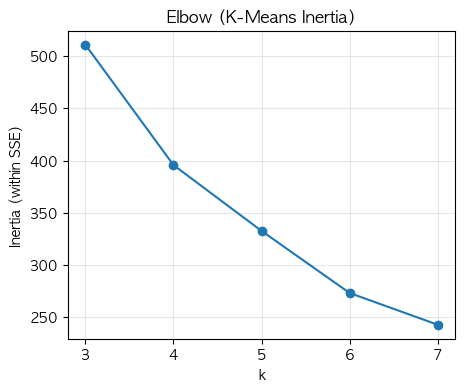

,model,k,n_clusters,noise_rate,silhouette,dbi,chi
3,KMeans,6,6,0.0,0.371,0.882,183.853
0,KMeans,3,3,0.0,0.351,1.121,169.353
4,KMeans,7,7,0.0,0.348,0.906,178.840
2,KMeans,5,5,0.0,0.348,0.957,174.303
1,KMeans,4,4,0.0,0.345,0.976,178.041


[Silhouette 기준 최적 K: 6]
[최종 프로파일용 K: 3]


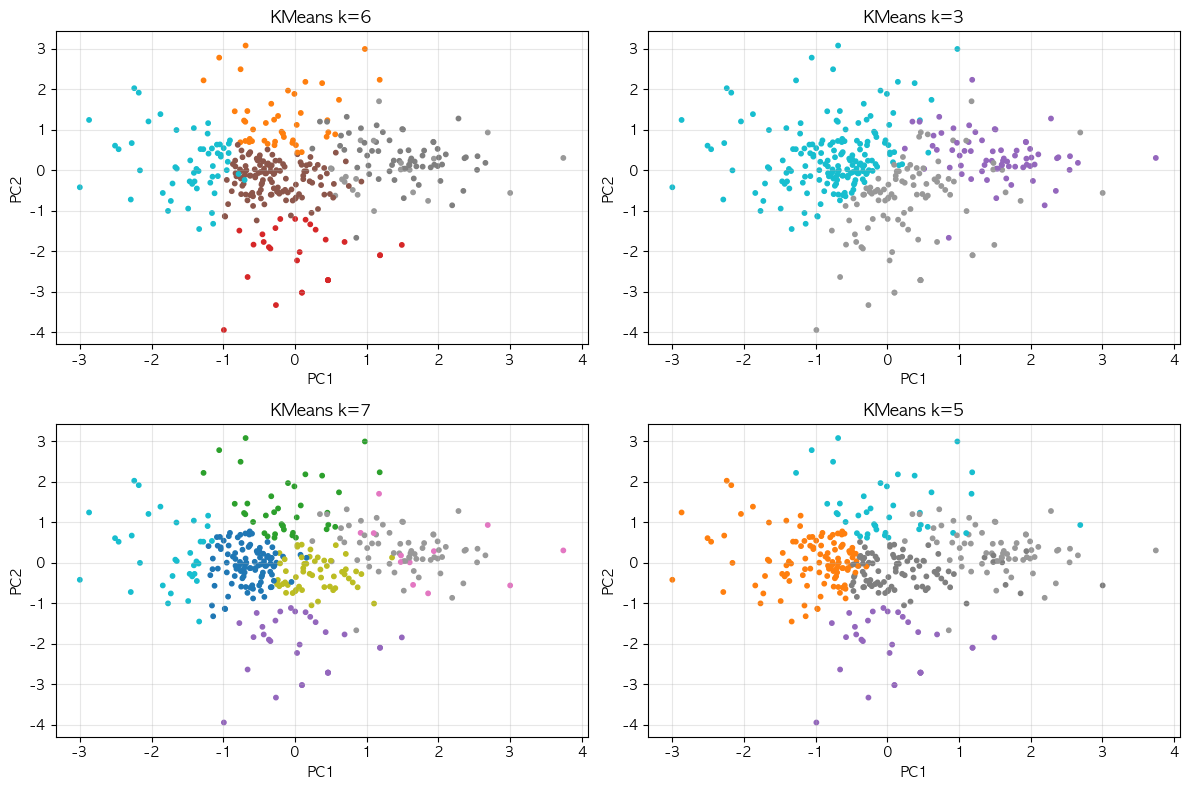

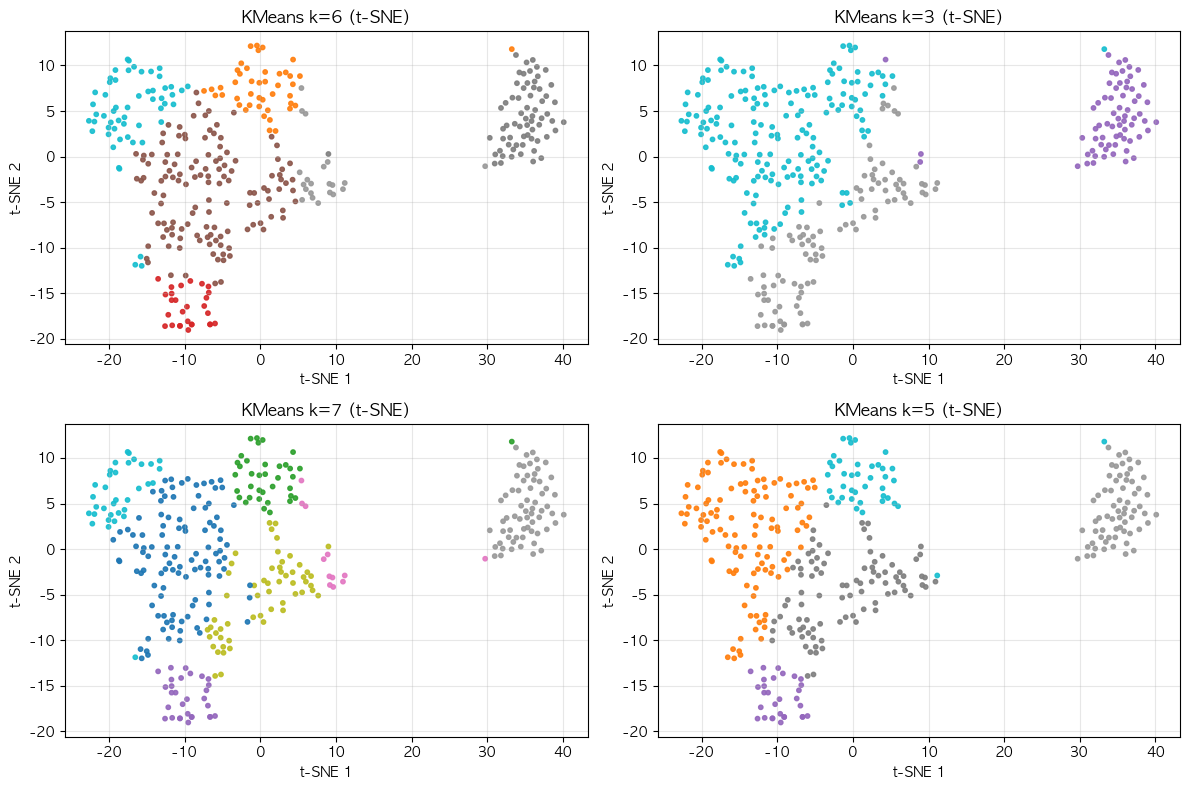


--- K-Means 프로파일 (최종 K 기준) ---


,count,avg_days_until_limit,med_days_until_limit,local_trade_ratio,avg_log_delay,med_log_delay,mean_delay_days_actual
cluster_km,,,,,,,
2,176,2.158,2.250,0.025,2.310,2.245,9.08
0,97,1.368,1.611,0.035,1.506,1.609,3.51
1,68,1.257,1.440,0.898,1.917,1.893,5.80


In [29]:

# 지연 데이터(메인)
features = [
    'avg_days_until_limit'
    ,'avg_log_delay'
    ,'local_trade_ratio']

delay_suite = run_clustering_suite(
    df=cluster_master_delay,
    features=features,
    k_list_km=(3,4,5,6,7),
    k_list_agg=(3,4,5,6),
    linkages=("ward","average"),
    top_n_vis=4,
    suite_name="DelayOnly",
    chosen_k=3
)

print("="*100)
print(" "*100)
print("="*100)

# 전체 데이터(비교군)
# all_suite = run_clustering_suite(
#     df=cluster_master_all,
#     features=features,
#     k_list_km=(3,4,5,6,7),
#     k_list_agg=(3,4,5,6),
#     linkages=("ward","average"),
#     top_n_vis=4,
#     suite_name="Overall"
# )
#kmeans, k=3, 실루엣=0.351, dbi=1.121, chi=169.353

**왜 K-Means, k = 3**

1. `AgglomerativeClustering`도 시도했으나, 실루엣은 높았지만 군집 비율이 98:1:1로 왜곡됨.

2. Best K 는 6이었으나 비교적 경계가 모호
   
3. `K-Means` k = 3는 실루엣, dbi, chi 전체적으로 낫뱃
   
4. 해석 가능성과 군집 균형을 고려해 `K-Means` k = 3로 결정


**PCA vs t-SNE**

- `PCA`는 전체 분산 방향을 기준으로 한 전역적 구조 아래 `t-SNE`는 유사도를 기준으로 한 비선형 구조

In [30]:
# K-Means(K=3)의 PCA 단독 그래프
def plot_clusters_pca_single(pca2, labels, title="K-Means (K=3) - PCA", save_path=None):
    base = plt.cm.get_cmap('tab10', 10)
    cmap = ListedColormap(['#999999'] + [base(i) for i in range(base.N)])
    color_idx = np.where(labels == -1, 0, labels + 1)

    centroids = np.array([pca2[labels == i].mean(axis=0) for i in np.unique(labels)])
    
    plt.figure(figsize=(7,5))
    plt.scatter(pca2[:,0], pca2[:,1], c=color_idx, cmap=cmap, s=25, alpha=0.9)
    # 중심점 + 군집번호 표시
    plt.scatter(centroids[:,0], centroids[:,1], c="black", s=90, marker="X", label="centroid")    
    for i, (x, y) in enumerate(centroids):
        plt.text(x, y+0.15, f"C{i}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3); plt.legend()
    if save_path: plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# K-Means(K=3)의 t-SNE 단독 그래프
def plot_clusters_tsne_single(tsne2, labels, title="K-Means (K=3) - t-SNE", save_path=None):
    base = plt.cm.get_cmap('tab10', 10)
    cmap = ListedColormap(['#999999'] + [base(i) for i in range(base.N)])
    color_idx = np.where(labels == -1, 0, labels + 1)

    centroids = np.array([tsne2[labels == i].mean(axis=0) for i in np.unique(labels)])
    
    plt.figure(figsize=(7,5))
    plt.scatter(tsne2[:,0], tsne2[:,1], c=color_idx, cmap=cmap, s=25, alpha=0.9)
    # 중심점 + 군집번호 표시
    plt.scatter(centroids[:,0], centroids[:,1], c="black", s=90, marker="X", label="centroid")
    for i, (x, y) in enumerate(centroids):
        plt.text(x, y+0.6, f"C{i}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    plt.title(title); plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.grid(alpha=0.3); plt.legend()
    if save_path: plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


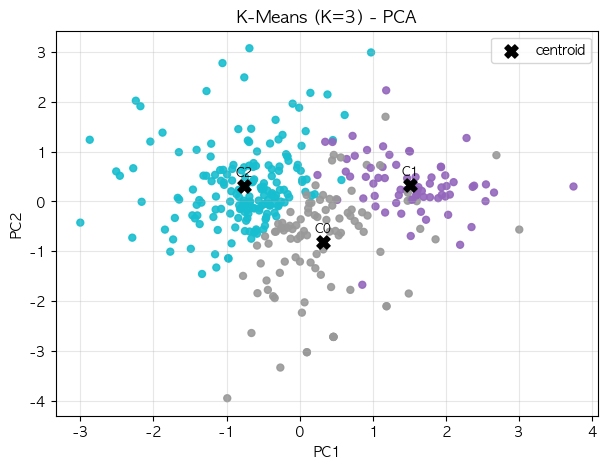

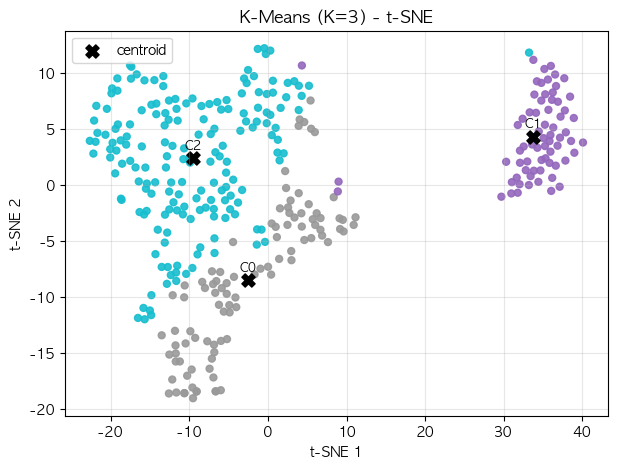

In [31]:
# 출력
labels = delay_suite["kmeans"]["labels"]
pca2   = delay_suite["kmeans"]["pca_embedding"]
tsne2  = delay_suite["kmeans"]["tsne_embedding"]

plot_clusters_pca_single(pca2, labels, save_path=None)
plot_clusters_tsne_single(tsne2, labels, save_path=None)


---

In [42]:
# 1. 군집 라벨
df_cluster_labels = delay_suite["kmeans"]["out"][[
    "customer_state", "product_category_group", "cluster_km"
]]

# 2. 추가 통계
df_stats = delay_df_clean.groupby(
    ["customer_state", "product_category_group"]
).agg(
    std_log_delay=('log_delay', 'std'),
    count=('product_id','count')
).reset_index()

# 3. 찐찐찐찐막.... = 기존 요약 + 군집라벨 + 추가통계
df_final = (
    cluster_master_delay
      .merge(df_cluster_labels, on=["customer_state","product_category_group"], how="left")
      .merge(df_stats,         on=["customer_state","product_category_group"], how="left")
)

df_final.head()


,customer_state,product_category_group,avg_days_until_limit,avg_log_delay,local_trade_ratio,cluster_km,std_log_delay,count
0,AC,baby_kids,3.00,3.465736,0.0,2,NaN,1
1,AC,electronics,1.00,3.218876,0.0,2,NaN,1
2,AC,furniture_home,-4.00,0.693147,0.0,0,NaN,1
3,AL,automotive,2.75,2.011397,0.0,2,0.416678,4
4,AL,baby_kids,1.50,2.227038,0.0,2,0.569297,4


---
## 추가

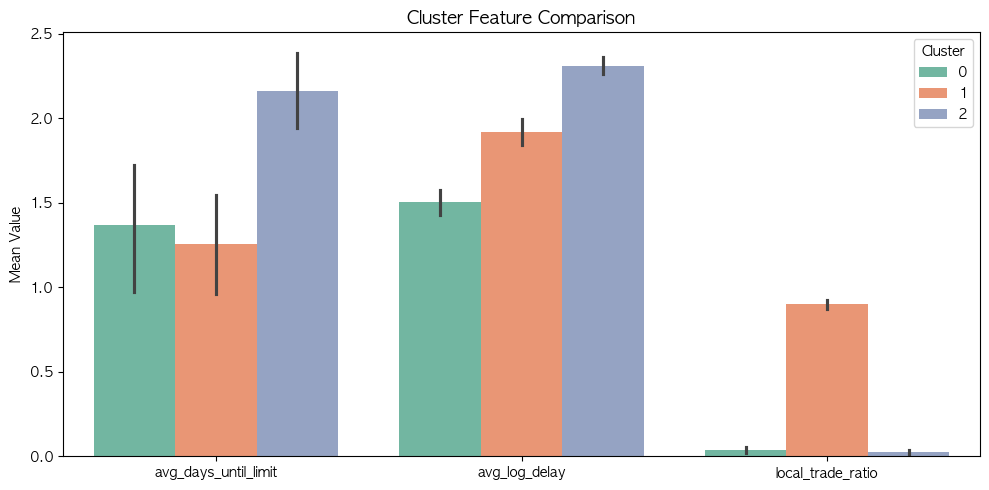

In [33]:
# 군집별 변수 차이
features = ['avg_days_until_limit', 'avg_log_delay', 'local_trade_ratio']

df_melt = df_final.melt(id_vars='cluster_km', value_vars=features, 
                        var_name='Feature', value_name='Value')

plt.figure(figsize=(10,5))
sns.barplot(data=df_melt, x='Feature', y='Value', hue='cluster_km', palette='Set2')
plt.title("Cluster Feature Comparison", fontsize=13, weight='bold')
#plt.xticks(rotation=45)
plt.ylabel("Mean Value")
plt.xlabel("")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

- **Cluster 2**: `avg_log_delay`와 `std_log_delay` 모두 높음 → 지연 크고 불안정

- **Cluster 0**: `local_trade_ratio` 높음, `std_log_delay` 낮음 → 로컬 중심 안정형

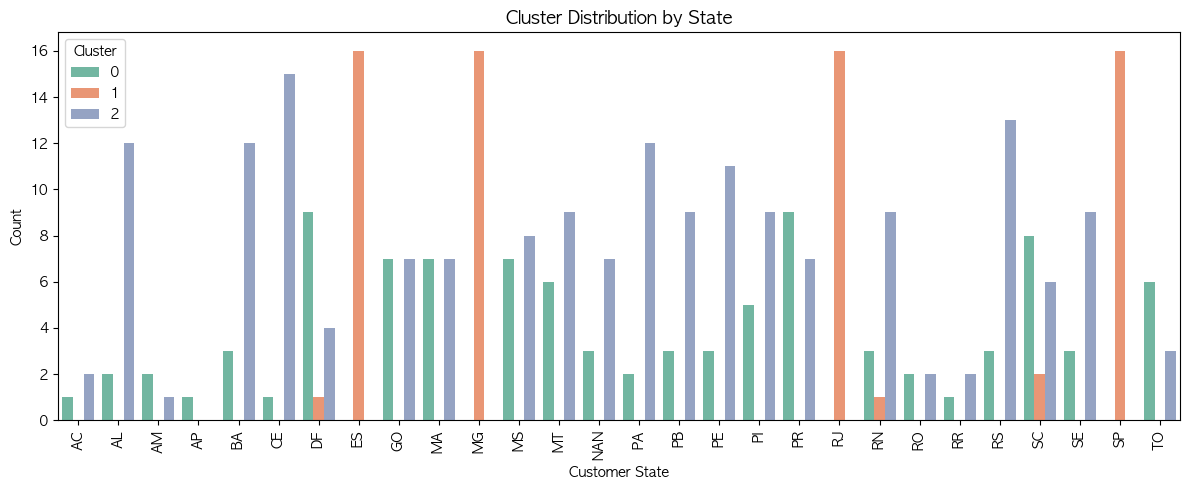

In [43]:
plt.figure(figsize=(12,5))
sns.countplot(data=df_final, x='customer_state', hue='cluster_km', palette='Set2')
plt.title("Cluster Distribution by State", fontsize=13, weight='bold')
plt.xticks(rotation=90)
plt.xlabel("Customer State")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

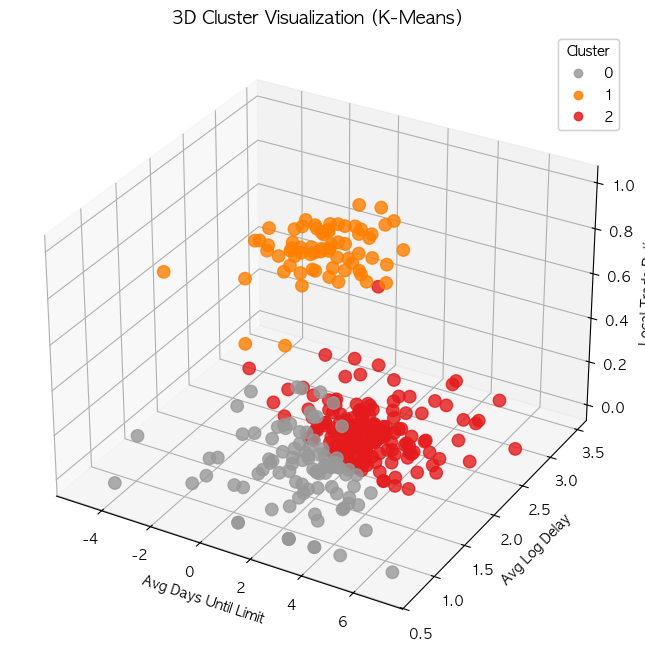

In [35]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# 산점도
scatter = ax.scatter(
    df_final['avg_days_until_limit'],
    df_final['avg_log_delay'],
    df_final['local_trade_ratio'],
    c=df_final['cluster_km'],       # 군집 색상
    cmap='Set1_r',                    # 팔레트
    s=80, alpha=0.8
)

# 축 이름
ax.set_xlabel('Avg Days Until Limit')
ax.set_ylabel('Avg Log Delay')
ax.set_zlabel('Local Trade Ratio')

# 범례
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)

plt.title('3D Cluster Visualization (K-Means)', fontsize=13, weight='bold')
plt.show()


<Axes: xlabel='product_category_group', ylabel='customer_state'>

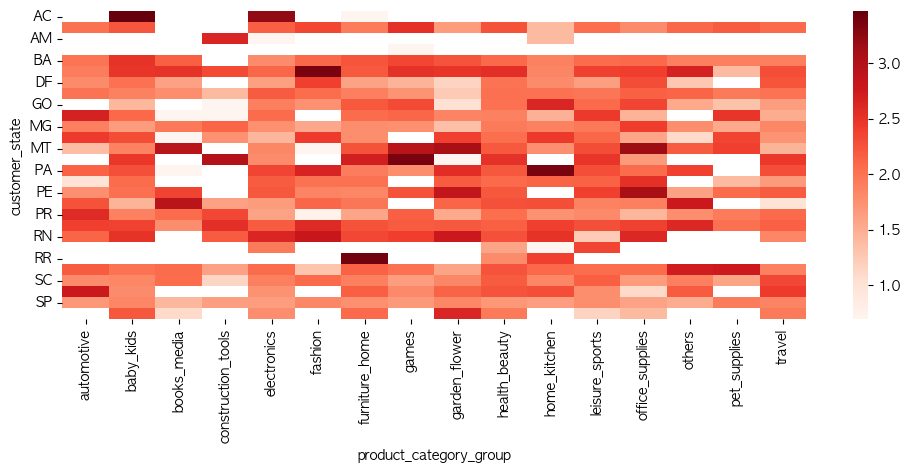

In [44]:
pivot = df_final.pivot_table(
    values='avg_log_delay',
    index='customer_state',
    columns='product_category_group',
    aggfunc='mean'
)
sns.heatmap(pivot, cmap='Reds')


**지연 집중도 Heatmap**

“어느 주에서 어떤 카테고리 지연이 반복적으로 심한가?”


- 붉은색이 진할수록 해당 지역-상품군 조합에서 지연이 구조적으로 심함

- 만약 특정 주의 여러 카테고리에서 다 붉다면, 그 주는 물류 인프라 문제 가능성이 큼.

- 반대로 특정 카테고리만 붉으면, 상품 특성(출고·포장·운송 난이도 등)이 원인일 수 있음.

In [37]:
df_final

,customer_state,product_category_group,avg_days_until_limit,avg_log_delay,local_trade_ratio,cluster_km,std_log_delay,count
0,AC,baby_kids,3.000000,3.465736,0.0,2,NaN,1
1,AC,electronics,1.000000,3.218876,0.0,2,NaN,1
2,AC,furniture_home,-4.000000,0.693147,0.0,0,NaN,1
3,AL,automotive,2.750000,2.011397,0.0,2,0.416678,4
4,AL,baby_kids,1.500000,2.227038,0.0,2,0.569297,4
...,...,...,...,...,...,...,...,...
336,TO,garden_flower,5.000000,2.639057,0.0,2,0.000000,2
337,TO,health_beauty,1.857143,1.944680,0.0,2,0.218104,7
338,TO,leisure_sports,0.000000,1.151293,0.0,0,0.647915,2
339,TO,office_supplies,-5.000000,1.386294,0.0,0,0.000000,2


<Axes: xlabel='product_category_group', ylabel='count'>

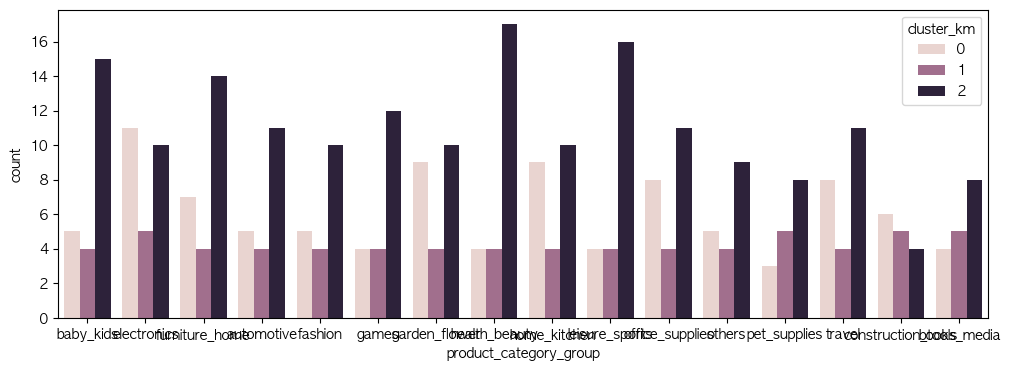

In [38]:
sns.countplot(data=df_final, x='product_category_group', hue='cluster_km')


**군집별 지역/카테고리 개수**

<Axes: xlabel='customer_state', ylabel='delay_label'>

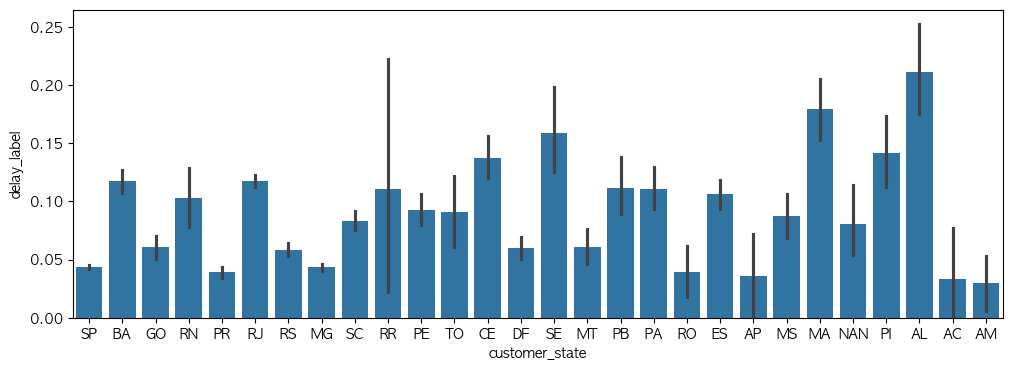

In [39]:
sns.barplot(data=full_orders_geo, x='customer_state', y='delay_label', estimator=np.mean)


<Axes: xlabel='customer_state'>

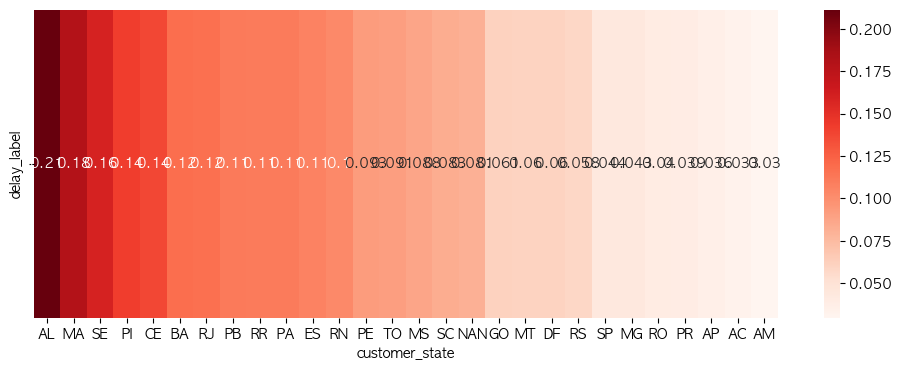

In [40]:
state_delay = full_orders_geo.groupby('customer_state')['delay_label'].mean().sort_values(ascending=False)
sns.heatmap(state_delay.to_frame().T, cmap='Reds', annot=True)


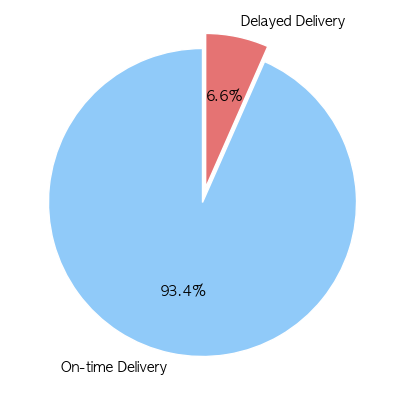

In [ ]:
# delay_counts = full_orders_geo['delay_label'].value_counts().sort_index()


# labels = ['On-time Delivery', 'Delayed Delivery']
# colors = ['#90CAF9', '#E57373']


# plt.figure(figsize=(5,5))
# plt.pie(delay_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors,explode=explode,
#         wedgeprops={'edgecolor': 'white', 'linewidth': 1})
# #plt.title('Proportion of Delayed Deliveries', fontsize=13, weight='bold')
# plt.show()
